In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Relationship Between Features**
### The CO₂ Emission dataset contains information about carbon dioxide emissions for different countries over different years.
### Features
Country : Name of the country.

Region : Geographical region of the country.

Date : Year of recorded emissions.

Kilotons of CO₂ : Total CO₂ emissions measured in kilotons.

Metric Tons Per Capita : Average CO₂ emissions per person.

### Relationship Between Features
Countries with larger industrial activities generally produce higher CO₂ emissions.

Population and industrialization influence total CO₂ emissions.

Metric Tons Per Capita shows the average emission produced by each individual.

Total CO₂ emissions and Per Capita emissions are related but may vary depending on population size.

Emission values change over different years.

# **Dataset Header**

In [7]:
df = pd.read_csv("co2_emmision.csv")
df.head()

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17


# **Dataset Understanding**

In [9]:
print("Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
display(df.isnull().sum())

Shape
(5677, 5)

Columns
Index(['Country', 'Region', 'Date', 'Kilotons of Co2',
       'Metric Tons Per Capita'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5677 entries, 0 to 5676
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 5677 non-null   object 
 1   Region                  5677 non-null   object 
 2   Date                    5677 non-null   object 
 3   Kilotons of Co2         5677 non-null   float64
 4   Metric Tons Per Capita  5677 non-null   float64
dtypes: float64(2), object(3)
memory usage: 221.9+ KB

Statistical Summary


,Kilotons of Co2,Metric Tons Per Capita
count,5.677000e+03,5677.000000
mean,1.412292e+05,4.325505
std,6.491258e+05,5.503834
min,0.000000e+00,0.000000
25%,1.380000e+03,0.570000
50%,9.170000e+03,2.360000
75%,5.848000e+04,6.340000
max,1.070722e+07,47.650000



Missing Values


,0
Country,0
Region,0
Date,0
Kilotons of Co2,0
Metric Tons Per Capita,0


# **Featuring Engineering**
Adding Emmision_Level column

In [11]:
median_emission = df["Kilotons of Co2"].median()
df["Emission_Level"] = (
    df["Kilotons of Co2"] > median_emission
).astype(int)
df.head()

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita,Emission_Level
0,Afghanistan,Asia,01-01-2011,8930.0,0.31,0
1,Afghanistan,Asia,01-01-2012,8080.0,0.27,0
2,Afghanistan,Asia,01-01-2010,7110.0,0.25,0
3,Afghanistan,Asia,01-01-2019,6080.0,0.16,0
4,Afghanistan,Asia,01-01-2018,6070.0,0.17,0


# **Visualization**

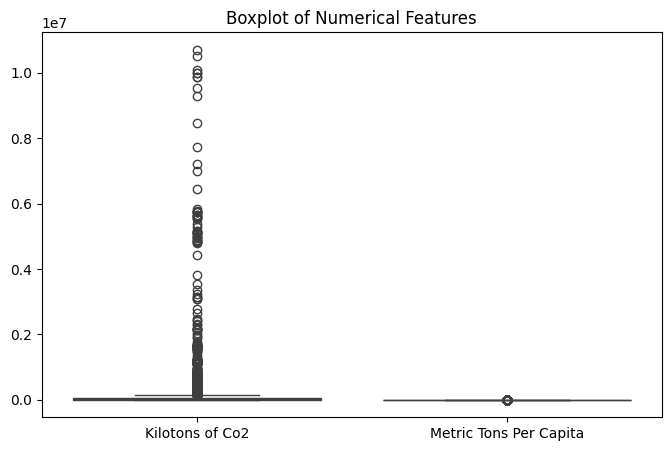

In [13]:
# boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Kilotons of Co2","Metric Tons Per Capita"]])
plt.title("Boxplot of Numerical Features")
plt.show()

# **Lable encoder**

In [14]:
le_country = LabelEncoder()
le_region = LabelEncoder()
df["Country"] = le_country.fit_transform(df["Country"])
df["Region"] = le_region.fit_transform(df["Region"])
print("Label Encoding Completed")
df.head()

Label Encoding Completed


,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita,Emission_Level
0,0,2,01-01-2011,8930.0,0.31,0
1,0,2,01-01-2012,8080.0,0.27,0
2,0,2,01-01-2010,7110.0,0.25,0
3,0,2,01-01-2019,6080.0,0.16,0
4,0,2,01-01-2018,6070.0,0.17,0


# **Train test split**

In [23]:
X = df[["Country", "Region", "Kilotons of Co2", "Metric Tons Per Capita"]]
y = df["Emission_Level"]
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4541, 4)
Testing Data Shape: (1136, 4)


# **Logistic Regression**

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison.head(10)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 100.0 %

Confusion Matrix
[[548   0]
 [  0 588]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1136
   macro avg       1.00      1.00      1.00      1136
weighted avg       1.00      1.00      1.00      1136



# **Insight**

- Logistic Regression was used to classify countries into High Emission and Low Emission categories.
- Feature Engineering was performed by creating the Emission_Level target column using the median CO₂ emission.
- Label Encoding converted categorical columns (Country and Region) into numerical values.
- The dataset was split into 80% training and 20% testing data.
- The model performance was evaluated using Accuracy, Confusion Matrix, and Classification Report.